In [220]:
import os

import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf



In [221]:
# Set TensorFlow threading optimizations before importing it
os.environ["TF_INTER_OP_PARALLELISM_THREADS"] = "4"
os.environ["TF_INTRA_OP_PARALLELISM_THREADS"] = "4"

# Load Data
df = pd.read_csv('dataset/Walmart.csv')

In [222]:
# Convert date columns to datetime
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

df.head()

# Group by Date and aggregate (e.g., sum for Weekly_Sales)
df = df.groupby('Date').agg({
  'Weekly_Sales': 'sum',
  'Holiday_Flag': 'max',
  'Temperature': 'mean',
  'Fuel_Price': 'mean',
  'CPI': 'mean',
  'Unemployment': 'mean'
}).reset_index()

df.head()

,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,2010-02-05,49750740.50,0,34.037333,2.717844,167.730885,8.619311
1,2010-02-12,48336677.63,1,34.151333,2.694022,167.825608,8.619311
2,2010-02-19,48276993.78,0,37.719778,2.672067,167.871686,8.619311
3,2010-02-26,43968571.13,0,39.243556,2.683933,167.909657,8.619311
4,2010-03-05,46871470.30,0,42.917333,2.731200,167.947628,8.619311


In [223]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Fit Holt-Winters Model (Triple Exponential Smoothing)
model = ExponentialSmoothing(df['Weekly_Sales'], trend='add', seasonal='add', seasonal_periods=52)
model_fit = model.fit()

# Add the forecast to the dataset
df['Holt_Winters_FC'] = model_fit.fittedvalues

/opt/anaconda3/envs/Demand-Forecast/lib/python3.12/site-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


In [224]:
df.head()

,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Holt_Winters_FC
0,2010-02-05,49750740.50,0,34.037333,2.717844,167.730885,8.619311,4.672636e+07
1,2010-02-12,48336677.63,1,34.151333,2.694022,167.825608,8.619311,4.812796e+07
2,2010-02-19,48276993.78,0,37.719778,2.672067,167.871686,8.619311,4.951315e+07
3,2010-02-26,43968571.13,0,39.243556,2.683933,167.909657,8.619311,4.480009e+07
4,2010-03-05,46871470.30,0,42.917333,2.731200,167.947628,8.619311,4.757745e+07


In [225]:
df['Lag 1'] = df['Weekly_Sales'].shift(1)
df['Lag 2'] = df['Weekly_Sales'].shift(2)
df['Lag 3'] = df['Weekly_Sales'].shift(3)
df['AR'] = 1
df = df.dropna()

In [226]:
features = df.drop(['Weekly_Sales', 'Date'], axis=1)
target = df['Weekly_Sales']

In [227]:
features.head()

,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Holt_Winters_FC,Lag 1,Lag 2,Lag 3,AR
3,0,39.243556,2.683933,167.909657,8.619311,4.480009e+07,48276993.78,48336677.63,49750740.50,1
4,0,42.917333,2.731200,167.947628,8.619311,4.757745e+07,43968571.13,48276993.78,48336677.63,1
5,0,47.432444,2.774422,167.985598,8.619311,4.515877e+07,46871470.30,43968571.13,48276993.78,1
6,0,49.954222,2.817089,167.930427,8.619311,4.542680e+07,45925396.51,46871470.30,43968571.13,1
7,0,48.473556,2.824111,167.859731,8.619311,4.335956e+07,44988974.64,45925396.51,46871470.30,1


In [228]:
target

3      43968571.13
4      46871470.30
5      45925396.51
6      44988974.64
7      44133961.05
          ...     
138    43734899.40
139    47566639.31
140    46128514.25
141    45122410.57
142    45544116.29
Name: Weekly_Sales, Length: 140, dtype: float64

In [229]:
from sklearn.preprocessing import StandardScaler

# standardization
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)
target_scaled = scaler.fit_transform(target.values.reshape(-1, 1))

In [230]:
features_scaled

array([[-0.26211122, -1.48294258, -1.63578502, ...,  0.22225333,
         0.47550869,  0.        ],
       [-0.26211122, -1.23489661, -1.52355108, ...,  0.21135063,
         0.21737565,  0.        ],
       [-0.26211122, -0.93004552, -1.42092061, ..., -0.57568689,
         0.20648054,  0.        ],
       ...,
       [-0.26211122, -0.19340959,  1.24398914, ..., -0.61837268,
        -0.50955062,  0.        ],
       [-0.26211122, -0.03388716,  1.20425611, ...,  0.08158722,
        -0.6226655 ,  0.        ],
       [-0.26211122, -0.01054095,  0.99408789, ..., -0.18112108,
         0.07680741,  0.        ]])

In [231]:
target_scaled

array([[-5.67696817e-01],
       [-3.76270196e-02],
       [-2.10380227e-01],
       [-3.81370992e-01],
       [-5.37496594e-01],
       [ 6.11034592e-01],
       [ 5.25446075e-02],
       [-3.45820125e-01],
       [-4.27846760e-01],
       [-6.15801805e-01],
       [ 2.60335000e-01],
       [-3.19085069e-01],
       [-3.57426011e-01],
       [ 1.24162596e-01],
       [ 5.68070945e-01],
       [ 1.36770069e-01],
       [ 9.94282509e-02],
       [-8.55475068e-02],
       [ 3.35975461e-01],
       [ 1.50096711e-01],
       [-1.52221521e-01],
       [-3.99653928e-01],
       [-4.46853452e-01],
       [ 2.05875531e-01],
       [-1.11954752e-01],
       [-3.02746651e-03],
       [-2.13239028e-01],
       [ 2.13139887e-02],
       [-2.63516625e-01],
       [-7.29817370e-01],
       [-1.04429354e+00],
       [-8.83356815e-01],
       [-3.60554651e-01],
       [-7.17264169e-01],
       [-7.32384178e-01],
       [-6.34481025e-01],
       [-2.36567757e-01],
       [-1.73968970e-01],
       [-3.5

In [232]:
train_dataset = tf.data.Dataset.from_tensor_slices((features_scaled, target_scaled))

train_dataset = train_dataset.batch(8).prefetch(tf.data.experimental.AUTOTUNE)

# Enable Mixed Precision Training for Speed-up (Only if GPU Available)
tf.keras.mixed_precision.set_global_policy('float32')

# Enable XLA Compilation for Faster Computation
tf.config.optimizer.set_jit(True)

# Neural Network Model (Optimized)
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(features_scaled.shape[1],)),  # Explicit Input layer

    tf.keras.layers.Dense(5),
    tf.keras.layers.ReLU(),

    tf.keras.layers.Dense(2),
    tf.keras.layers.ReLU(),

    tf.keras.layers.Dense(1)
])


In [ ]:
# Compile Model with Adjusted Learning Rate
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

In [256]:
# Train Model with validation dataset and include early stopping
history = model.fit(
    train_dataset,
    epochs=200,
    verbose=1,
)

Epoch 1/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 669us/step - loss: 0.0476 - mae: 0.1500
Epoch 2/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 619us/step - loss: 0.0471 - mae: 0.1478
Epoch 3/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 640us/step - loss: 0.0471 - mae: 0.1478
Epoch 4/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 615us/step - loss: 0.0471 - mae: 0.1481
Epoch 5/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 601us/step - loss: 0.0471 - mae: 0.1481
Epoch 6/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 437us/step - loss: 0.0471 - mae: 0.1481
Epoch 7/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 452us/step - loss: 0.0471 - mae: 0.1483
Epoch 8/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 434us/step - loss: 0.0471 - mae: 0.1482
Epoch 9/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 385us/step - loss: 0.0471 - mae: 0.1481
Epoch 10/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 359us/step - loss: 0.0471 - mae: 0.1481
Epoch 11/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 344us/step - loss: 0.0471 - mae: 0.1482
Epoch 12/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 344us/step - loss: 0.0471 - mae: 0.1483
Epoch 13/200


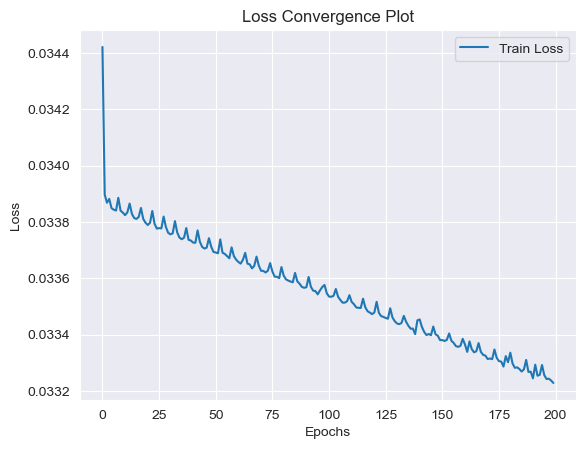

In [257]:
# Plot Training Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title("Loss Convergence Plot")
plt.show()# Compile Model with Adjusted Learning Rate

In [258]:
predictions = model.predict(features_scaled)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


In [259]:
predictions

array([[-0.19228742],
       [-0.19228742],
       [-0.19228742],
       [-0.19228742],
       [-0.43157992],
       [-0.25729102],
       [-0.19228742],
       [-0.19228742],
       [-0.19228742],
       [-0.2686185 ],
       [-0.19228742],
       [-0.19228742],
       [-0.342053  ],
       [-0.19228742],
       [ 0.28931874],
       [ 0.14392269],
       [ 0.1557801 ],
       [-0.07205218],
       [ 0.19051501],
       [ 0.16431236],
       [-0.25794554],
       [-0.25794554],
       [-0.44959974],
       [ 0.2240093 ],
       [-0.05707708],
       [-0.07660699],
       [-0.03596391],
       [ 0.14951643],
       [-0.25794554],
       [-0.61464304],
       [-0.984113  ],
       [-0.9983932 ],
       [-0.19228742],
       [-0.63515264],
       [-0.64154744],
       [-0.49964523],
       [-0.19228742],
       [-0.19228742],
       [-0.19228742],
       [ 3.5089161 ],
       [ 0.39527532],
       [ 1.6847439 ],
       [ 2.8181107 ],
       [ 5.9300656 ],
       [-0.88539004],
       [-0

In [260]:
target_scaled

array([[-5.67696817e-01],
       [-3.76270196e-02],
       [-2.10380227e-01],
       [-3.81370992e-01],
       [-5.37496594e-01],
       [ 6.11034592e-01],
       [ 5.25446075e-02],
       [-3.45820125e-01],
       [-4.27846760e-01],
       [-6.15801805e-01],
       [ 2.60335000e-01],
       [-3.19085069e-01],
       [-3.57426011e-01],
       [ 1.24162596e-01],
       [ 5.68070945e-01],
       [ 1.36770069e-01],
       [ 9.94282509e-02],
       [-8.55475068e-02],
       [ 3.35975461e-01],
       [ 1.50096711e-01],
       [-1.52221521e-01],
       [-3.99653928e-01],
       [-4.46853452e-01],
       [ 2.05875531e-01],
       [-1.11954752e-01],
       [-3.02746651e-03],
       [-2.13239028e-01],
       [ 2.13139887e-02],
       [-2.63516625e-01],
       [-7.29817370e-01],
       [-1.04429354e+00],
       [-8.83356815e-01],
       [-3.60554651e-01],
       [-7.17264169e-01],
       [-7.32384178e-01],
       [-6.34481025e-01],
       [-2.36567757e-01],
       [-1.73968970e-01],
       [-3.5

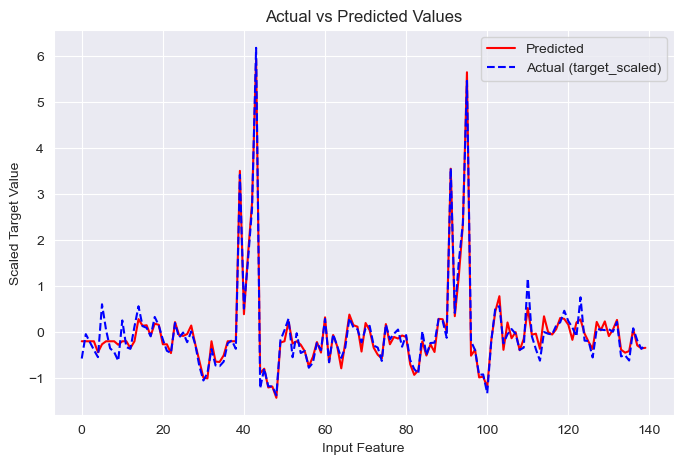

In [261]:
# Plot actual vs. predicted values
plt.figure(figsize=(8, 5))
plt.plot(range(target_scaled.shape[0]), predictions, label="Predicted", color="red", linestyle="solid")
plt.plot(range(target_scaled.shape[0]), target_scaled, label="Actual (target_scaled)", color="blue", linestyle="dashed")
plt.xlabel("Input Feature")
plt.ylabel("Scaled Target Value")
plt.title("Actual vs Predicted Values")
plt.legend()
plt.show()

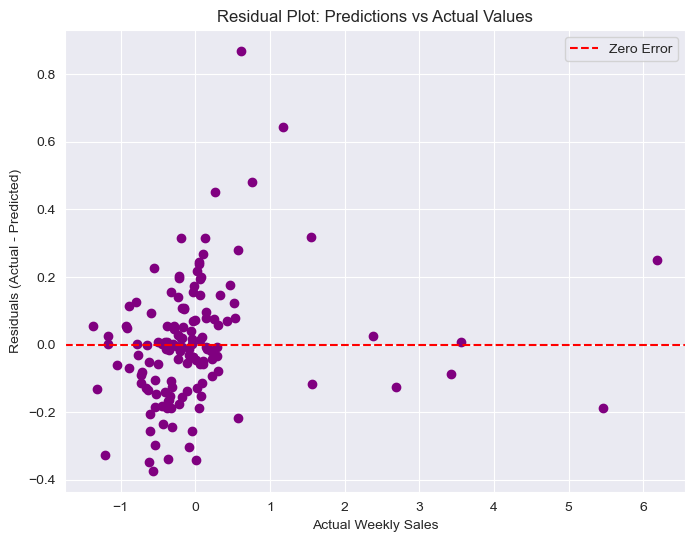

In [262]:
# Residual Plot
residuals = target_scaled - predictions
plt.figure(figsize=(8, 6))
plt.scatter(target_scaled, residuals, color='purple')
plt.axhline(y=0, color='red', linestyle="--", label="Zero Error")
plt.xlabel("Actual Weekly Sales")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot: Predictions vs Actual Values")
plt.legend()
plt.grid(True)
plt.show()